# Ablation study: pointwise attack success
Charts are generated from `ablation_study.csv`.

In [29]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidates = [Path('ablation_study.csv'), Path('Results/ablation_study.csv'), Path.cwd().parent / 'Results' / 'ablation_study.csv']
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('ablation_study.csv not found. Run: python Results/update_ablation_study.py')
df = pd.read_csv(csv_path)
if 'Setting' not in df.columns and 'Reasoning effort' in df.columns:
    df = df.rename(columns={'Reasoning effort': 'Setting'})
df.head()

,Setting,Dataset,Model,Paradigm,Attack,Prompt,Passages,Requested,Valid attacked,Discarded,Attack success,Attack success (%),Date,Source
0,low,TREC-DL-2019,GPT-OSS-20B,Pointwise,DCH,Default,1000,1000,1000,0,874,87.4,2026-09-15 17:52:11,LLM_prompt_attack/outputs/reasoning_ablation/g...
1,low,TREC-DL-2019,GPT-OSS-20B,Pointwise,DCH,Defense,1000,1000,1000,0,25,2.5,2026-09-15 18:34:49,LLM_prompt_attack/outputs/reasoning_ablation/g...
2,low,TREC-DL-2019,GPT-OSS-20B,Pointwise,DOH,Default,1000,1000,1000,0,92,9.2,2026-09-15 16:36:21,LLM_prompt_attack/outputs/reasoning_ablation/g...
3,low,TREC-DL-2019,GPT-OSS-20B,Pointwise,DOH,Defense,1000,1000,1000,0,38,3.8,2026-09-15 17:42:34,LLM_prompt_attack/outputs/reasoning_ablation/g...
4,medium,TREC-DL-2019,GPT-OSS-20B,Pointwise,DCH,Default,1000,1000,999,1,819,81.9,2026-09-15 19:55:58,LLM_prompt_attack/outputs/reasoning_ablation/g...


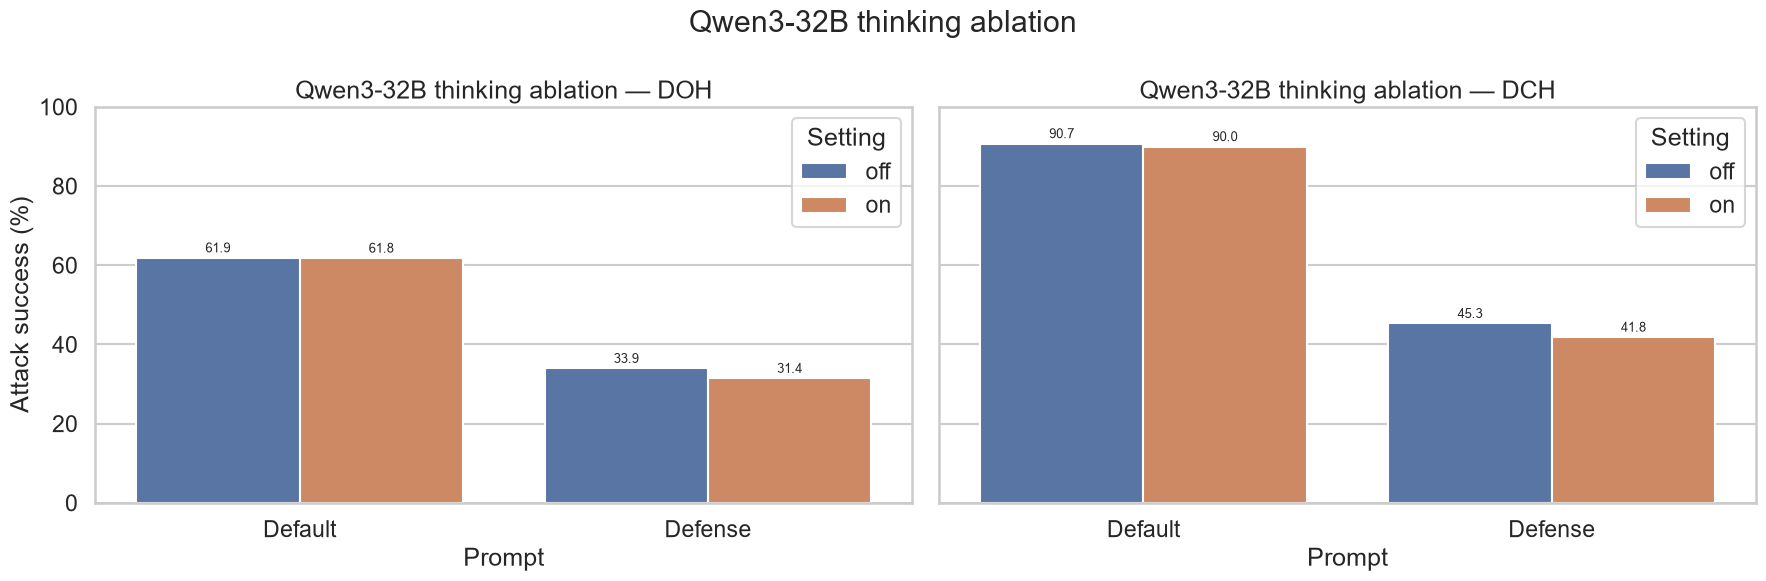

In [30]:
sns.set_theme(style='whitegrid', context='talk')

def plot_model(model, title, order):
    subset = df[df['Model'].eq(model)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    for ax, attack in zip(axes, ['DOH', 'DCH']):
        attack_data = subset[subset['Attack'].eq(attack)].copy()
        sns.barplot(data=attack_data, x='Prompt', y='Attack success (%)', hue='Setting', hue_order=order, errorbar=None, ax=ax)
        ax.set_title(f'{title} — {attack}')
        ax.set_xlabel('Prompt')
        ax.set_ylabel('Attack success (%)')
        ax.set_ylim(0, 100)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=2, fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_model('Qwen3-32B', 'Qwen3-32B thinking ablation', ['off', 'on'])

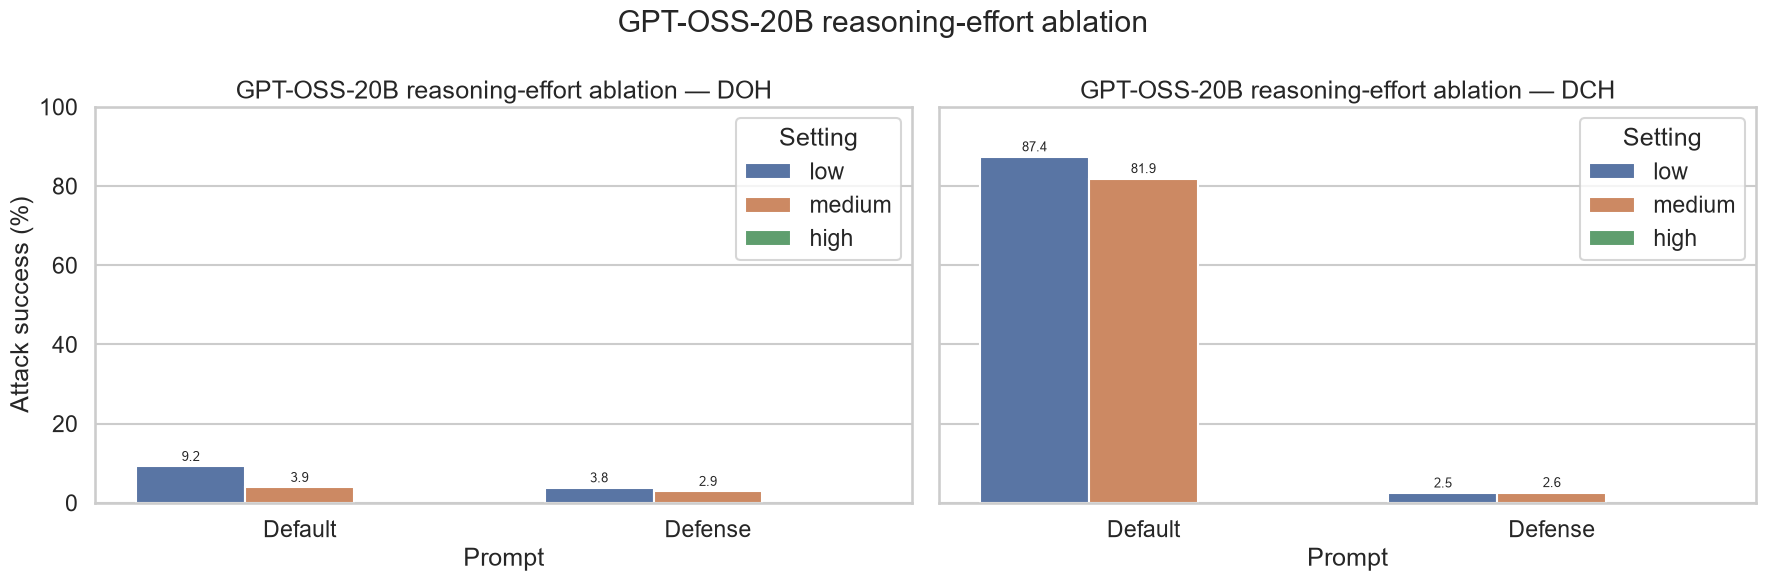

In [31]:
plot_model('GPT-OSS-20B', 'GPT-OSS-20B reasoning-effort ablation', ['low', 'medium', 'high'])

## Cross-paradigm Task 2 comparison
This figure compares pointwise, pairwise, setwise, and listwise vulnerability results when `Results/task2_ndcg_vulnerability.csv` is available.

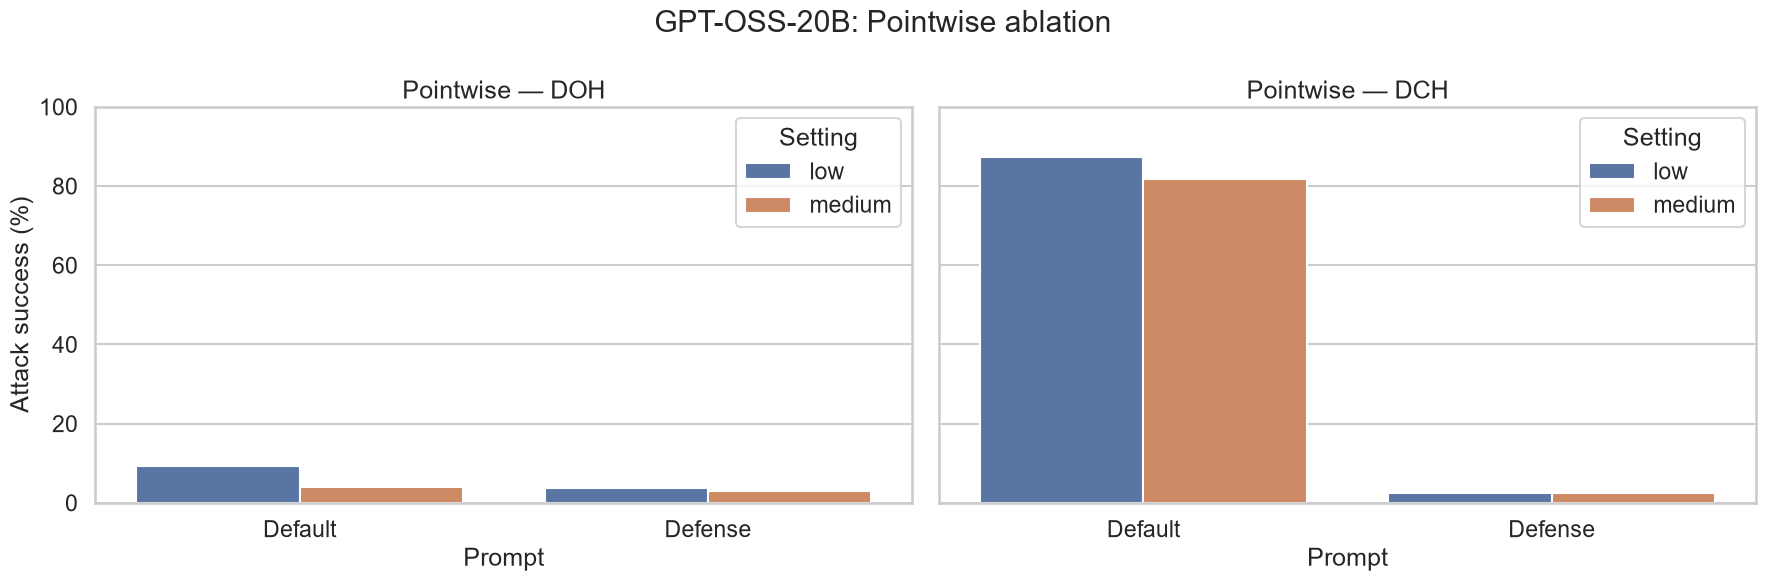

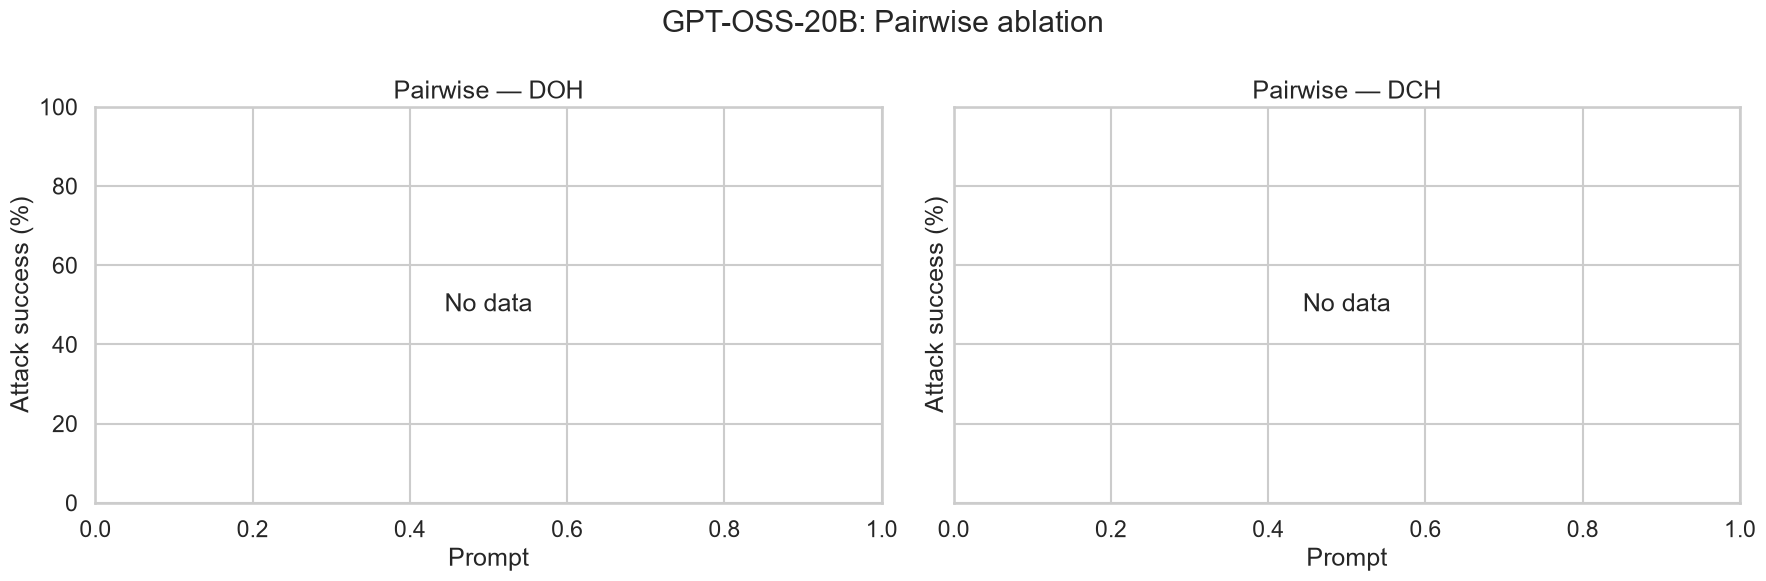

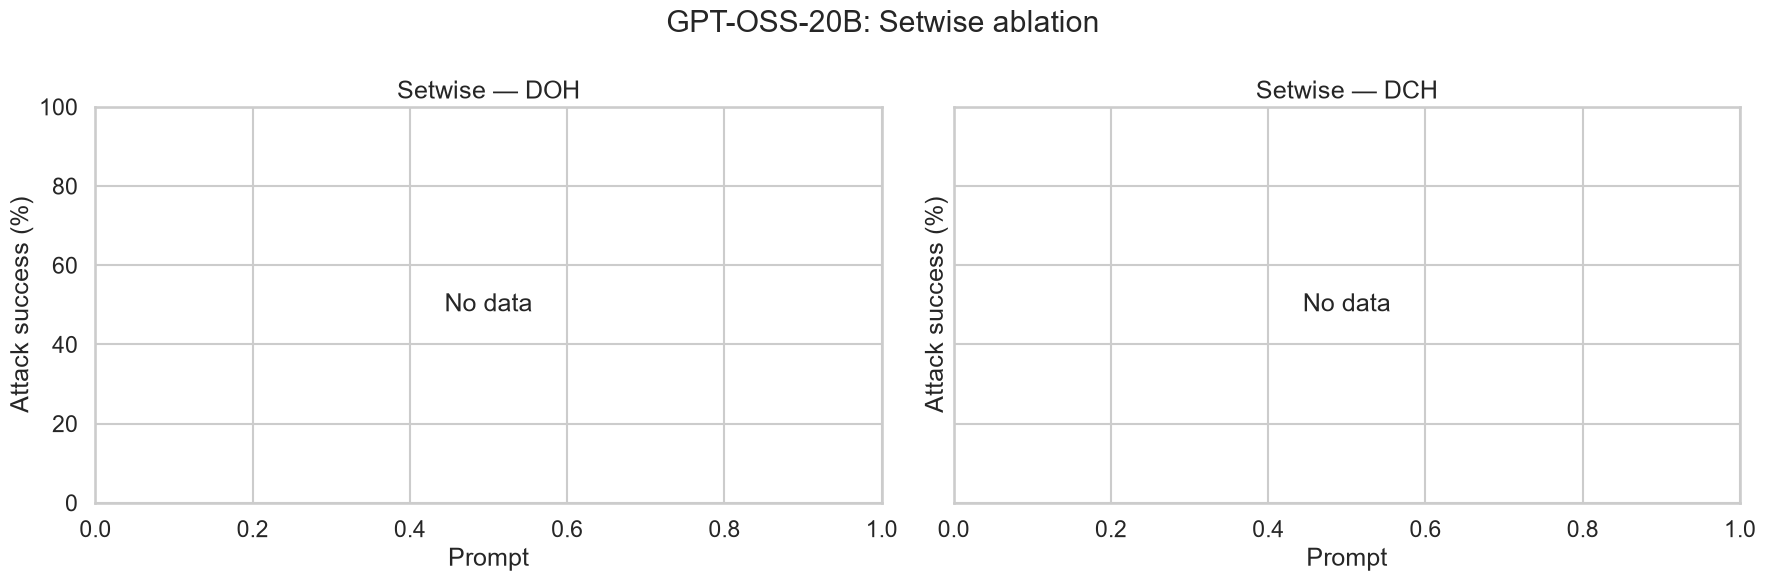

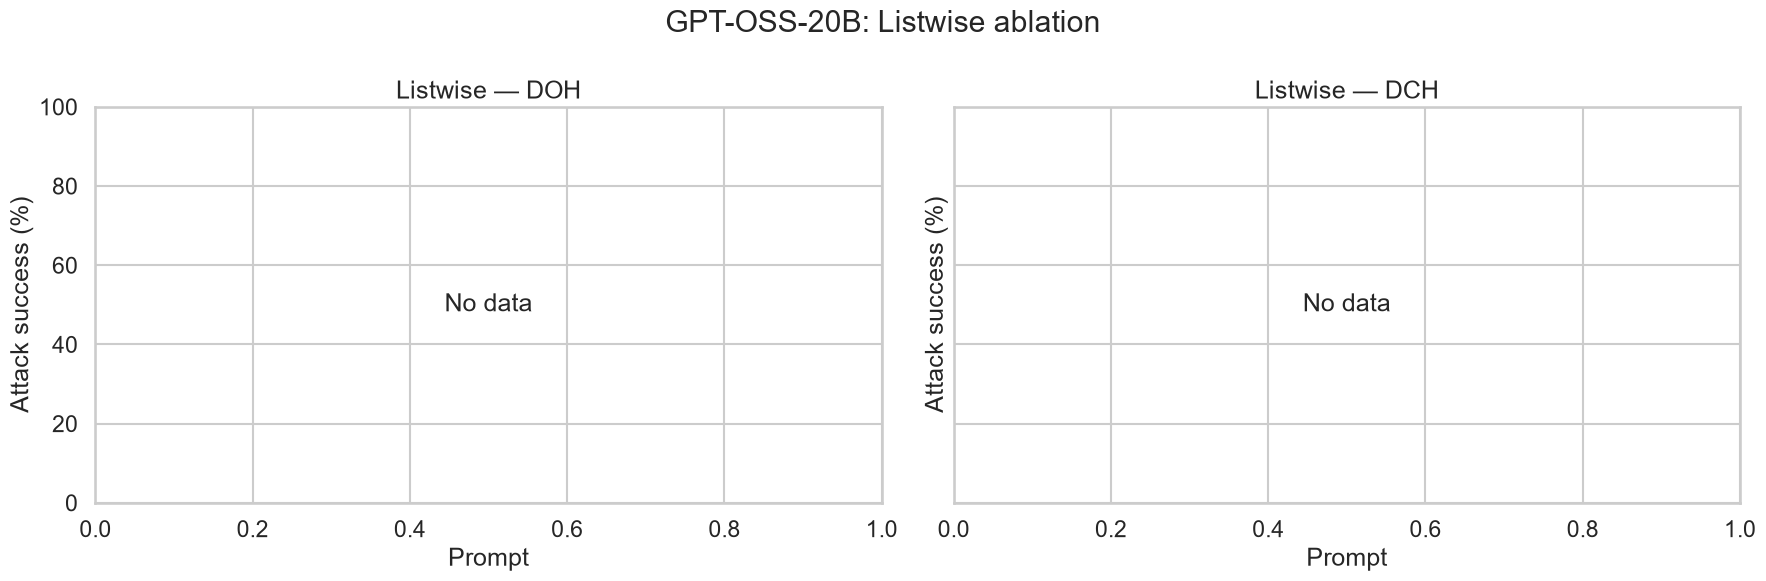

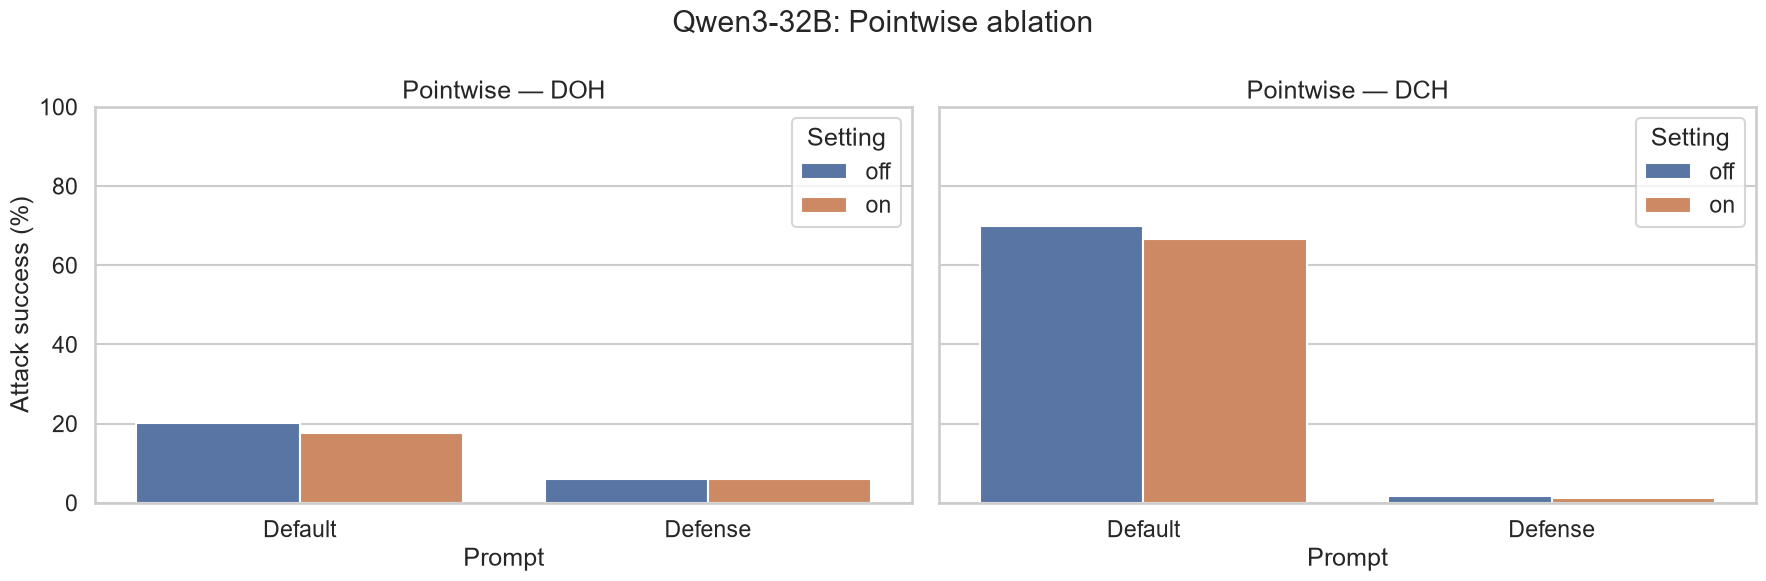

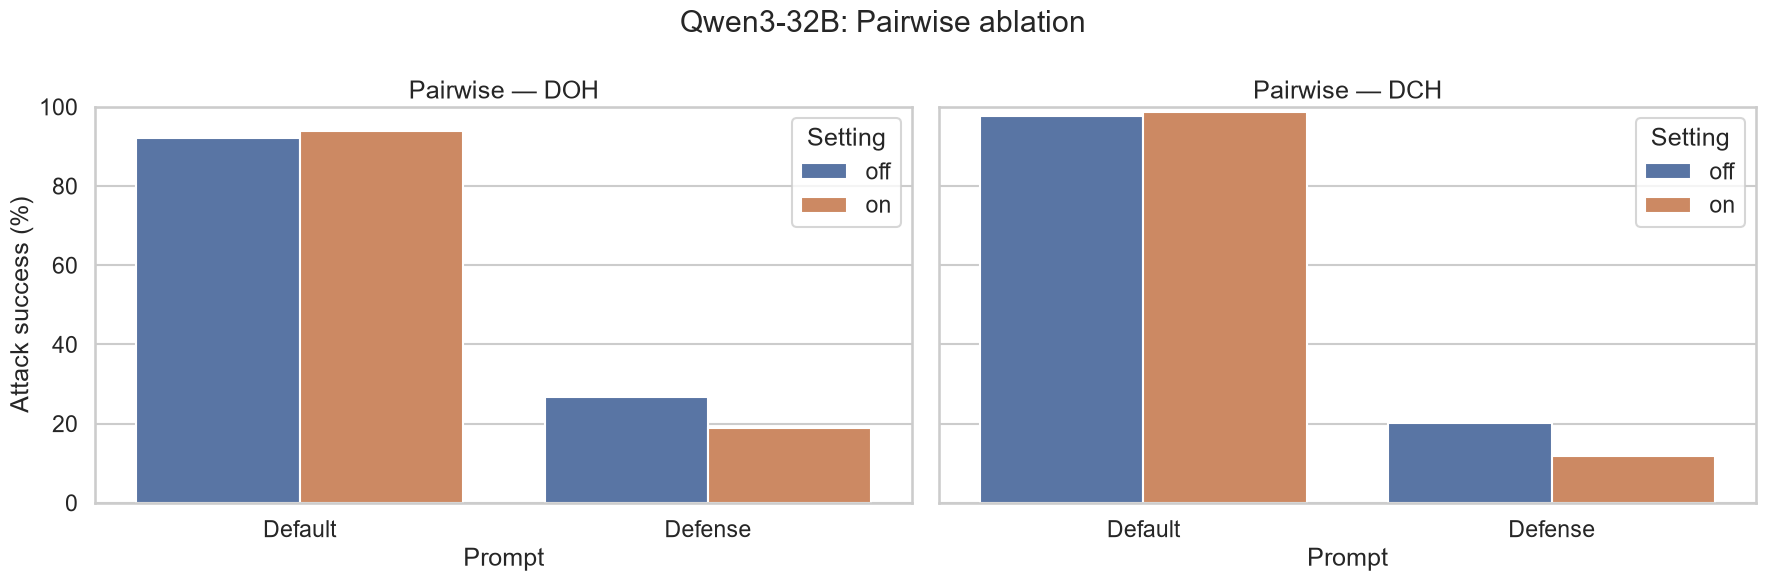

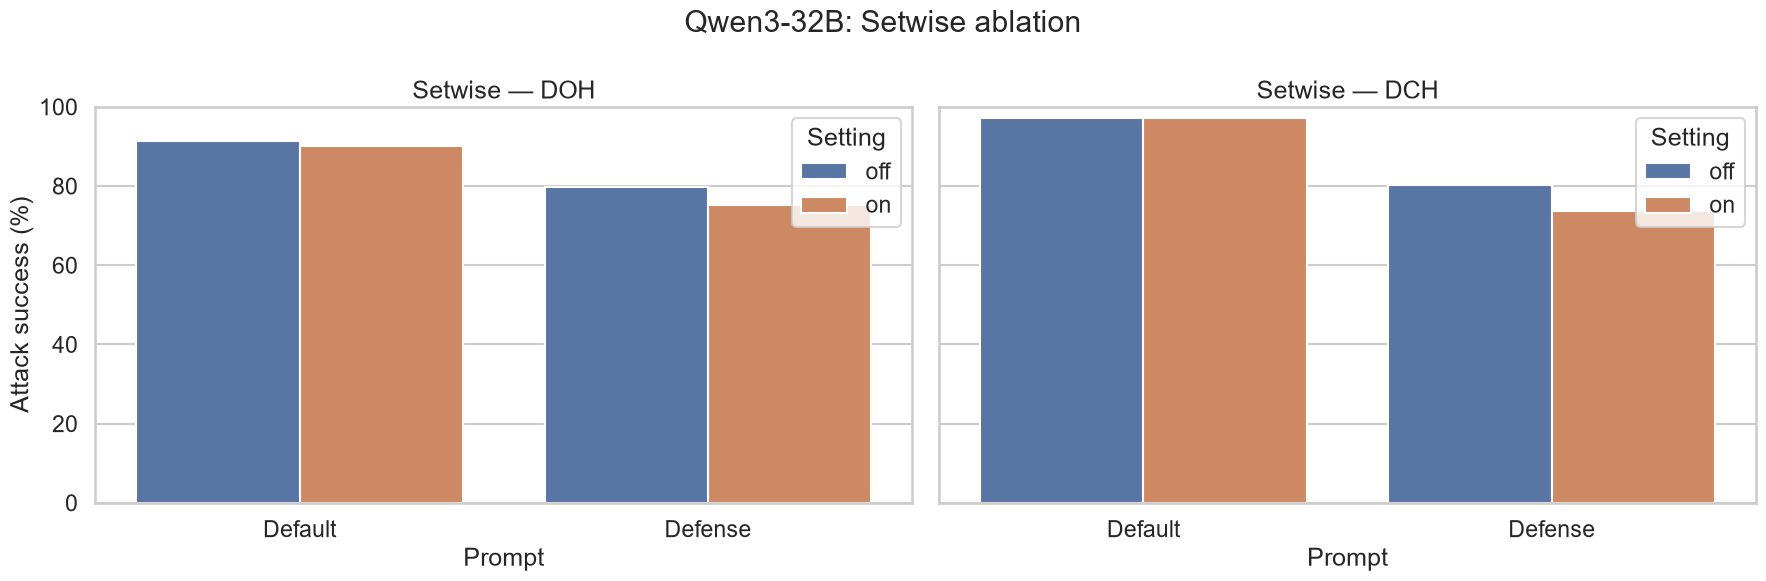

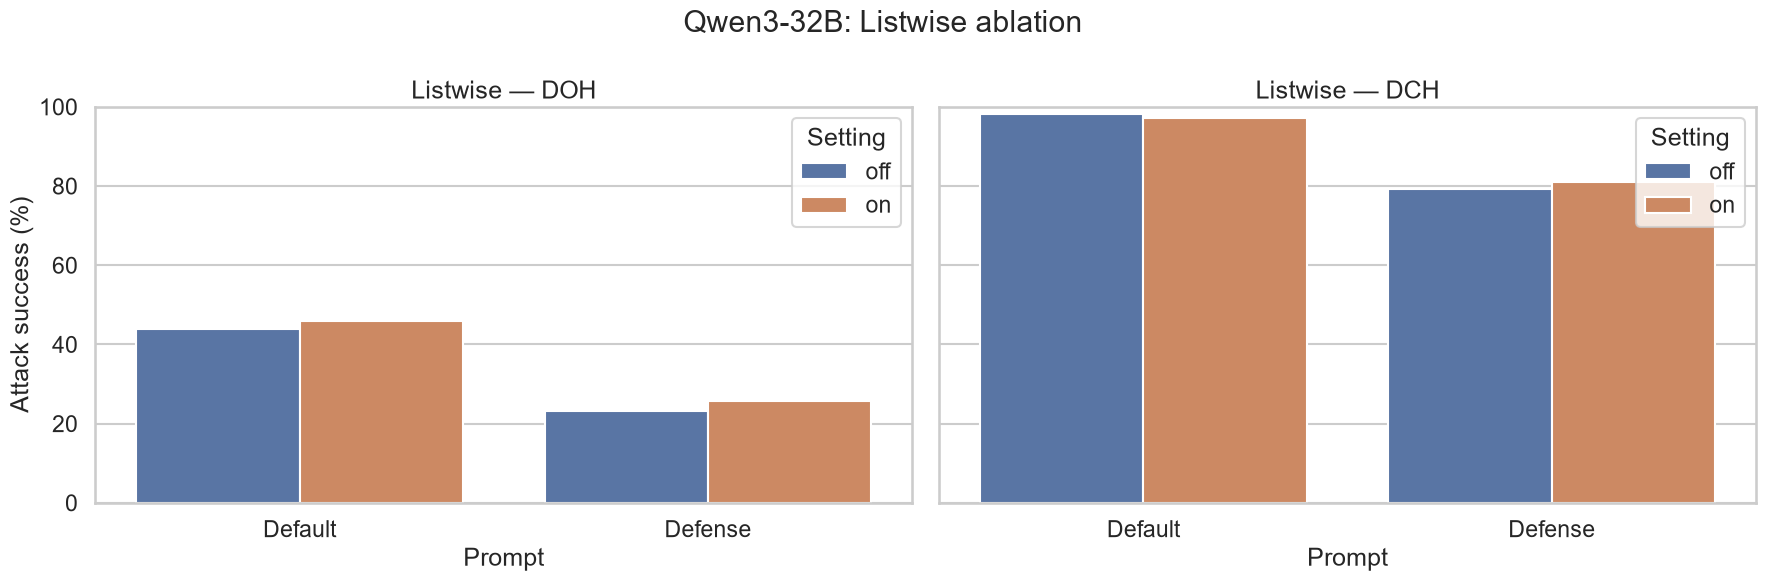

In [32]:
task2_path = Path('Results/ablation_study.csv')
if not task2_path.exists():
    task2_path = Path('ablation_study.csv')
if task2_path.exists():
    task2 = pd.read_csv(task2_path)
    if 'Paradigm' not in task2.columns and 'run' in task2.columns:
        task2['Paradigm'] = task2['run'].str.extract(r'\.(pointwise|pairwise|setwise|listwise)\.')
    if 'Paradigm' not in task2.columns:
        print('This CSV is an older pointwise-only export. Regenerate it with Results/update_ablation_study.py.')
        task2 = pd.DataFrame()
    task2 = task2.dropna(subset=['Paradigm']) if not task2.empty else task2
    if 'Model' in task2.columns:
        task2 = task2.rename(columns={'Model': 'model'})
    task2['model'] = task2['model'].replace({'openai.gpt-oss-20b-1:0': 'GPT-OSS-20B', 'gpt-oss-20b': 'GPT-OSS-20B'})
    if 'condition' in task2.columns:
        task2['Attack'] = task2['condition'].replace({'doh': 'DOH', 'dch': 'DCH', 'qi': 'QI', 'clean': 'Clean', 'bm25': 'BM25'})
    if not task2.empty:
        for model in sorted(task2['model'].dropna().unique()):
            for paradigm in ['Pointwise', 'Pairwise', 'Setwise', 'Listwise']:
                view = task2[task2['model'].eq(model) & task2['Paradigm'].eq(paradigm)].copy()
                view['Series'] = view['Prompt'].astype(str) + ' / ' + view['Setting'].astype(str)
                fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
                for ax, attack in zip(axes, ['DOH', 'DCH']):
                    attack_view = view[view['Attack'].eq(attack)].copy()
                    if paradigm == 'Listwise' and attack == 'DOH':
                        attack_view = attack_view[attack_view['Setting'].ne('baseline')]
                    if attack_view.empty:
                        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                    else:
                        sns.barplot(data=attack_view, x='Prompt', y='Attack success (%)', hue='Setting', errorbar=None, ax=ax)
                    ax.set_title(f'{paradigm} — {attack}'); ax.set_xlabel('Prompt'); ax.set_ylabel('Attack success (%)'); ax.set_ylim(0, 100)
                fig.suptitle(f'{model}: {paradigm} ablation'); fig.tight_layout(); plt.show()
else:
    print('Run Results/evaluate_task2_ndcg.py first to create task2_ndcg_vulnerability.csv')